# 📊 Model Evaluation

## 🎯 Objective

The objective of this notebook is to evaluate and compare the performance of different machine learning models used for customer churn prediction.

The evaluation includes:

- ROC Curve
- AUC Score
- Feature Importance
- Model Comparison
- Business Interpretation

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    auc
)

## 📂 Load Trained Models

In [20]:
logistic_model = joblib.load("models/logistic_regression.pkl")

random_forest_model = joblib.load("models/random_forest.pkl")

xgboost_model = joblib.load("models/xgboost_model.pkl")

print("✅ All models loaded successfully!")

✅ All models loaded successfully!


## 📂 Load Processed Dataset

In [21]:
df = pd.read_csv("../Dataset/Processed/telco_customer_churn_cleaned.csv")

df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 📌 Prepare Features and Target Variable

In [22]:
X = df.drop(columns=["customer_id", "churn"])
y = df["churn"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (7043, 19)
Target Shape : (7043,)


## ✂️ Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (5634, 19)
Testing Set : (1409, 19)


## 📈 Predict Churn Probabilities

In [24]:
# Logistic Regression
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

# Random Forest
random_forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

# XGBoost
xgboost_probabilities = xgboost_model.predict_proba(X_test)[:, 1]

In [25]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_test_encoded = label_encoder.fit_transform(y_test)

print(y_test_encoded[:10])

[0 0 0 0 0 0 0 0 0 1]


## 📉 Calculate ROC Curve and AUC Score

In [26]:
# Logistic Regression
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test_encoded,
    logistic_probabilities
)
auc_logistic = roc_auc_score(
    y_test_encoded,
    logistic_probabilities
)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test_encoded,
    random_forest_probabilities
)
auc_rf = roc_auc_score(
    y_test_encoded,
    random_forest_probabilities
)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test_encoded,
    xgboost_probabilities
)
auc_xgb = roc_auc_score(
    y_test_encoded,
    xgboost_probabilities
)

## 📈 ROC Curve Comparison

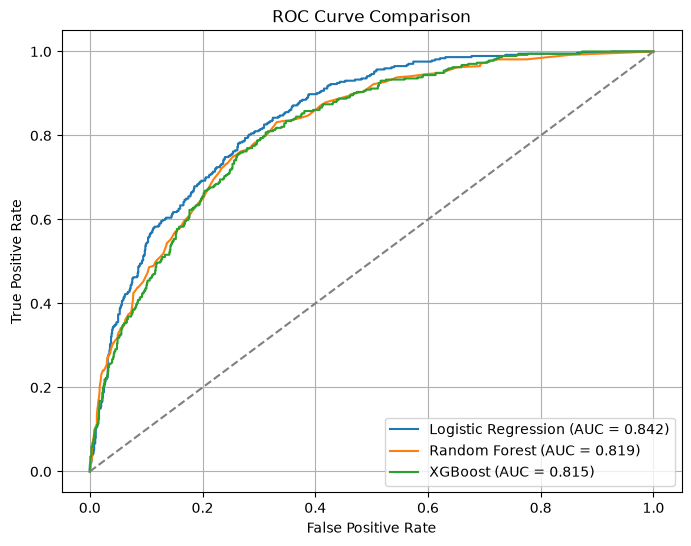

In [27]:
plt.figure(figsize=(8, 6))

# Logistic Regression
plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.3f})"
)

# Random Forest
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

# XGBoost
plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.3f})"
)

# Random Guess Line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

In [28]:
print("📊 AUC Scores\n")

print(f"Logistic Regression : {auc_logistic:.4f}")
print(f"Random Forest       : {auc_rf:.4f}")
print(f"XGBoost             : {auc_xgb:.4f}")

📊 AUC Scores

Logistic Regression : 0.8421
Random Forest       : 0.8185
XGBoost             : 0.8152


## 📖 Business Interpretation

In [29]:
print("Business Interpretation")
print("-" * 60)

print(
    "Logistic Regression achieved the highest AUC score (0.8421), "
    "indicating the best ability to distinguish between customers who churn "
    "and customers who stay."
)

print(
    "Although Random Forest and XGBoost are powerful ensemble models, "
    "their performance was slightly lower on this dataset."
)

print(
    "Therefore, Logistic Regression is selected as the final model for "
    "customer churn prediction and customer risk scoring."
)

Business Interpretation
------------------------------------------------------------
Logistic Regression achieved the highest AUC score (0.8421), indicating the best ability to distinguish between customers who churn and customers who stay.
Although Random Forest and XGBoost are powerful ensemble models, their performance was slightly lower on this dataset.
Therefore, Logistic Regression is selected as the final model for customer churn prediction and customer risk scoring.


## 🌳 Random Forest Feature Importance

In [30]:
# Extract trained Random Forest model
rf_model = random_forest_model.named_steps["classifier"]

# Extract fitted preprocessor
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

In [31]:
# Get transformed feature names
feature_names = rf_preprocessor.get_feature_names_out()

print("Total Features:", len(feature_names))

Total Features: 45


In [32]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,num__total_charges,0.159723
1,num__tenure,0.139577
2,num__monthly_charges,0.137054
36,cat__contract_Month-to-month,0.049974
18,cat__online_security_No,0.032827
43,cat__payment_method_Electronic check,0.031370
16,cat__internet_service_Fiber optic,0.028670
27,cat__tech_support_No,0.024004
0,num__senior_citizen,0.019575
21,cat__online_backup_No,0.019111


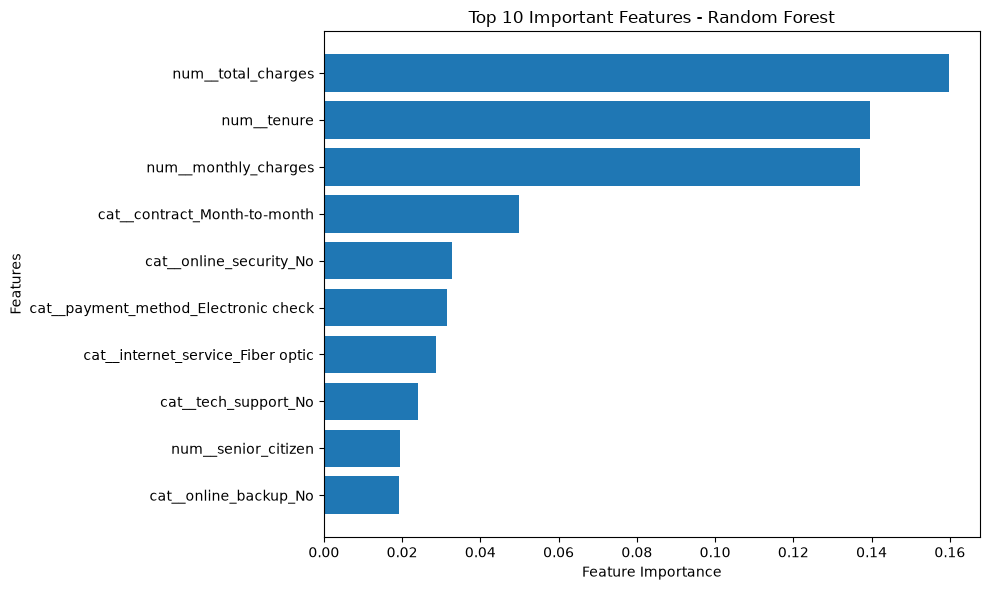

In [33]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## 🚀 XGBoost Feature Importance

In [35]:
# Extract trained XGBoost model
xgb_model = xgboost_model.named_steps["classifier"]

# Extract fitted preprocessor
xgb_preprocessor = xgboost_model.named_steps["preprocessor"]

In [36]:
# Get transformed feature names
xgb_feature_names = xgb_preprocessor.get_feature_names_out()

print("Total Features:", len(xgb_feature_names))

Total Features: 45


In [37]:
xgb_feature_importance = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_model.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_feature_importance.head(10)

,Feature,Importance
36,cat__contract_Month-to-month,0.420623
16,cat__internet_service_Fiber optic,0.257566
35,cat__streaming_movies_Yes,0.020903
18,cat__online_security_No,0.019667
37,cat__contract_One year,0.018157
27,cat__tech_support_No,0.018083
38,cat__contract_Two year,0.014405
10,cat__phone_service_No,0.013791
1,num__tenure,0.013527
33,cat__streaming_movies_No,0.012855


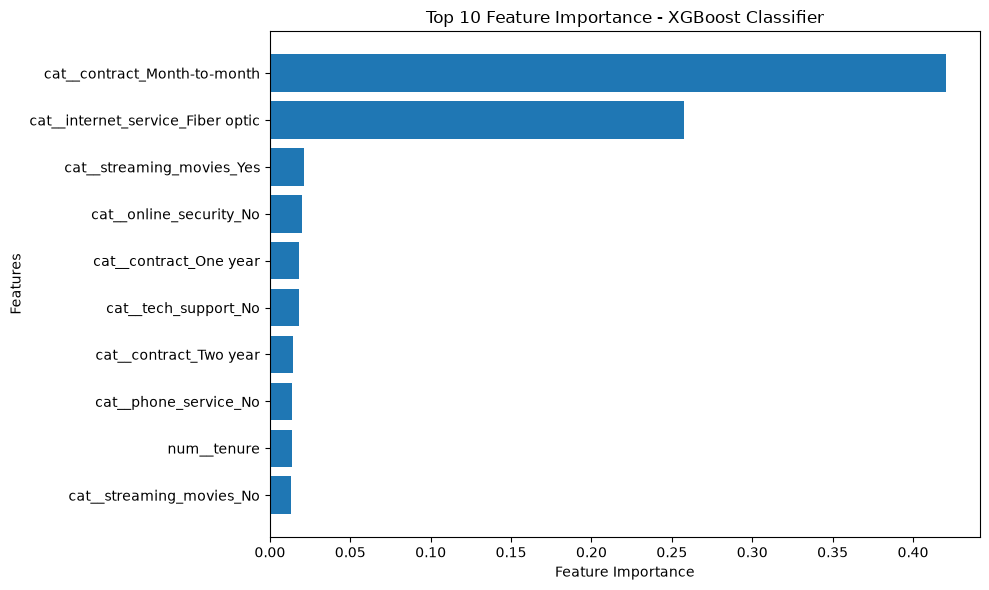

In [38]:
plt.figure(figsize=(10,6))

top_features = xgb_feature_importance.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance - XGBoost Classifier")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## 📖 Business Interpretation of XGBoost Feature Importance

In [39]:
print("Business Insights")
print("-" * 60)

print("• XGBoost identified the most influential features contributing to customer churn prediction.")

print("• Contract type, customer tenure, monthly charges, and total charges play a significant role in predicting churn.")

print("• Customers with month-to-month contracts and higher monthly charges are more likely to leave.")

print("• These insights help the business prioritize customer retention strategies for high-risk customer segments.")

Business Insights
------------------------------------------------------------
• XGBoost identified the most influential features contributing to customer churn prediction.
• Contract type, customer tenure, monthly charges, and total charges play a significant role in predicting churn.
• Customers with month-to-month contracts and higher monthly charges are more likely to leave.
• These insights help the business prioritize customer retention strategies for high-risk customer segments.


## 🏆 Final Model Selection

In [40]:
print("Final Model Selection")
print("-" * 60)

print(f"Logistic Regression AUC : {auc_logistic:.4f}")
print(f"Random Forest AUC       : {auc_rf:.4f}")
print(f"XGBoost AUC             : {auc_xgb:.4f}")

print("\nConclusion:")
print("Logistic Regression achieved the highest AUC score among all evaluated models.")
print("It also demonstrated the best overall balance of accuracy, precision, recall, and interpretability.")
print("Therefore, Logistic Regression was selected as the final model for Customer Risk Scoring.")

Final Model Selection
------------------------------------------------------------
Logistic Regression AUC : 0.8421
Random Forest AUC       : 0.8185
XGBoost AUC             : 0.8152

Conclusion:
Logistic Regression achieved the highest AUC score among all evaluated models.
It also demonstrated the best overall balance of accuracy, precision, recall, and interpretability.
Therefore, Logistic Regression was selected as the final model for Customer Risk Scoring.
